In [1]:
from copy import deepcopy
import warnings
from pathlib import Path
import os 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.burgers import (
    BurgersMultiTrajectoryGLSConfig,
    build_burgers_weak_validation_blocks,
    fit_burgers_multi_trajectory_coefficients,
    generate_burgers_dataset,
    get_burgers_feature_names,
    run_burgers_multi_trajectory_gls_experiment,
)
from mfsindy.cases.burgers_plots import COLORS_MODELS
from mfsindy.experiments import (
    evaluate_weak_form_models,
    format_coefficient_equations,
    make_metric_scorer,
    optimize_hyperparams,
    split_trajectory_list,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
if not RESULTS_DIR.exists():
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
elif not RESULTS_DIR.is_dir():
    raise NotADirectoryError(f"{RESULTS_DIR} exists and is not a directory")

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]
cfg = BurgersMultiTrajectoryGLSConfig(
    n_runs=25,
    K = 100,
    n_lf=100,
    n_hf=10,
    results_dir=str(RESULTS_DIR),
    results_filename="burgers_part1_errors.csv",
)


# Burgers Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Burgers equation using the multi-trajectory (Part 1) workflow.

## Governing equations

The one-dimensional viscous Burgers equation is

$$
\partial_t u + u\partial_x u = \nu\partial_{xx} u,
$$

where $u(x,t)$ is the state variable and $\nu$ is the viscosity coefficient.

We use viscosity $\nu$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.

### Trajectory snapshot
Preview noisy LF/HF trajectories and a clean reference.

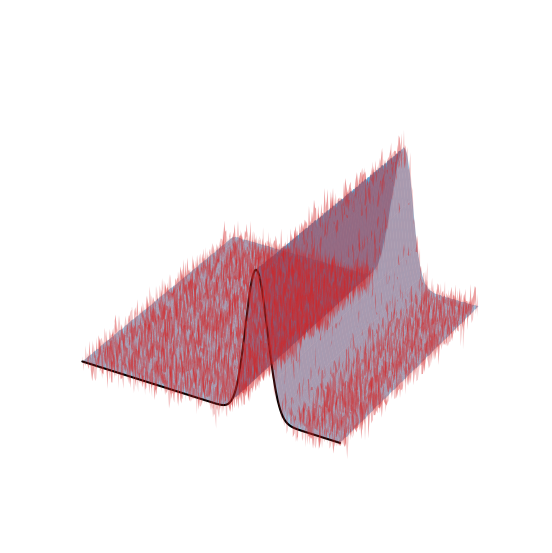

In [2]:
from mfsindy.cases.burgers_plots import plot_multifidelity_trajectories
X_ref, t_ref, x_ref,_ = generate_burgers_dataset(
    n_traj=1,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

X_hf_noisy, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_hf_rel*np.std(X_ref),
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

X_lf_noisy, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_lf_rel*np.std(X_ref),
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)
plot_multifidelity_trajectories(X_hf_noisy, X_lf_noisy, X_ref, x_ref, t_ref)


### Hyperparameter Selection

Use one HF/LF ensemble draw, split trajectories 80-20 into train and validation sets, tune the weak-form hyperparameters separately for each model by maximizing held-out weak-form $R^2$, then refit on the full ensemble and print the resulting equations.


In [3]:
# H_X_CANDIDATES = [cfg.L / 50.0, cfg.L / 20.0, cfg.L / 10.0]
# H_T_CANDIDATES = [cfg.T_train / 50.0, cfg.T_train / 20.0, cfg.T_train / 10.0]

# SEARCH_GRID = {
#     "stlsq_threshold": [0.025, 0.05, 0.1],
#     "H_xt": [[h_x, h_t] for h_x in H_X_CANDIDATES for h_t in H_T_CANDIDATES],
# }

# X_ref_search, t_search, x_search, _ = generate_burgers_dataset(
#     n_traj=1,
#     T=cfg.T_train,
#     dt=cfg.dt,
#     noise_level=0.0,
#     seed=cfg.seed_base,
#     L=cfg.L,
#     NX=cfg.NX,
#     nu=cfg.nu,
# )
# state_std = float(np.std(X_ref_search[0]))
# noise_hf_abs = cfg.noise_hf_rel * state_std
# noise_lf_abs = cfg.noise_lf_rel * state_std

# X_hf_search, _, _, _ = generate_burgers_dataset(
#     n_traj=cfg.n_hf,
#     T=cfg.T_train,
#     dt=cfg.dt,
#     noise_level=noise_hf_abs,
#     seed=cfg.seed_base,
#     L=cfg.L,
#     NX=cfg.NX,
#     nu=cfg.nu,
# )
# X_lf_search, _, _, _ = generate_burgers_dataset(
#     n_traj=cfg.n_lf,
#     T=cfg.T_train,
#     dt=cfg.dt,
#     noise_level=noise_lf_abs,
#     seed=cfg.seed_base + 100,
#     L=cfg.L,
#     NX=cfg.NX,
#     nu=cfg.nu,
# )

# hf_train, hf_val = split_trajectory_list(X_hf_search, validation_fraction=0.2)
# lf_train, lf_val = split_trajectory_list(X_lf_search, validation_fraction=0.2)

# search_results = {}
# best_params_by_model = {}
# tuned_cfg_by_model = {}
# tuned_equations = {}

# def evaluate_candidate(candidate_cfg):
#     coef_map = fit_burgers_multi_trajectory_coefficients(
#         candidate_cfg,
#         hf_trajectories=hf_train,
#         lf_trajectories=lf_train,
#         t_grid=t_search,
#         x_grid=x_search,
#         noise_hf_abs=noise_hf_abs,
#         noise_lf_abs=noise_lf_abs,
#         weak_seed=candidate_cfg.seed_base + 40_000,
#     )
#     validation_blocks = (
#         build_burgers_weak_validation_blocks(
#             candidate_cfg,
#             hf_val,
#             t_grid=t_search,
#             x_grid=x_search,
#             weak_seed=candidate_cfg.seed_base + 40_010,
#             group_name="HF validation",
#         )
#         + build_burgers_weak_validation_blocks(
#             candidate_cfg,
#             lf_val,
#             t_grid=t_search,
#             x_grid=x_search,
#             weak_seed=candidate_cfg.seed_base + 40_020,
#             group_name="LF validation",
#         )
#     )
#     return evaluate_weak_form_models(coef_map, validation_blocks)

# for target_model in MODELS:
#     search = optimize_hyperparams(
#         cfg,
#         param_grid=SEARCH_GRID,
#         evaluate=evaluate_candidate,
#         score_fn=make_metric_scorer(source=target_model, metric="weak_r2"),
#         maximize=True,
#     )
#     tuned_cfg = deepcopy(search.best_config)
#     search_results[target_model] = search
#     best_params_by_model[target_model] = search.best_params
#     tuned_cfg_by_model[target_model] = tuned_cfg
#     full_coef_map = fit_burgers_multi_trajectory_coefficients(
#         tuned_cfg,
#         hf_trajectories=X_hf_search,
#         lf_trajectories=X_lf_search,
#         t_grid=t_search,
#         x_grid=x_search,
#         noise_hf_abs=noise_hf_abs,
#         noise_lf_abs=noise_lf_abs,
#         weak_seed=tuned_cfg.seed_base + 40_001,
#     )
#     tuned_equations[target_model] = full_coef_map[target_model]

# feature_names = get_burgers_feature_names(
#     cfg,
#     t_grid=t_search,
#     x_grid=x_search,
#     reference_trajectory=X_hf_search[0],
# )
# print(pd.DataFrame(best_params_by_model).T)
# print(
#     format_coefficient_equations(
#         tuned_equations,
#         feature_names=feature_names,
#         state_names=("u_t",),
#         precision=3,
#     )
# )


### Run

In [4]:
# df_errors_parts = []
# for model_name in MODELS:
#     method_cfg = deepcopy(tuned_cfg_by_model[model_name])
#     method_cfg.results_dir = str(RESULTS_DIR)
#     method_cfg.results_filename = f"burgers_part1_{model_name.lower()}_errors.csv"
#     df_model, _, _, _, _, _ = run_burgers_multi_trajectory_gls_experiment(method_cfg)
#     df_errors_parts.append(df_model[df_model["model"] == model_name].copy())

# df_errors = pd.concat(df_errors_parts, ignore_index=True)
# df_errors.to_csv(Path(cfg.results_dir) / cfg.results_filename, index=False)



## Errors

In [5]:
errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)
def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)

print("Mean Absolute Error")
print(mae_summary)
print("Support Fraction Error")
print(l0_summary)


Mean Absolute Error
         median       q25       q75
model                              
HF     0.183333  0.183333  0.183333
LF     0.244788  0.183333  0.250052
MF     0.231821  0.069720  0.244923
MF_w   0.002456  0.001663  0.003089
Support Fraction Error
       median  q25  q75
model                  
HF        1.0  1.0  1.0
LF        1.5  1.0  1.5
MF        1.0  1.0  1.5
MF_w      0.0  0.0  0.0


### L1 Error

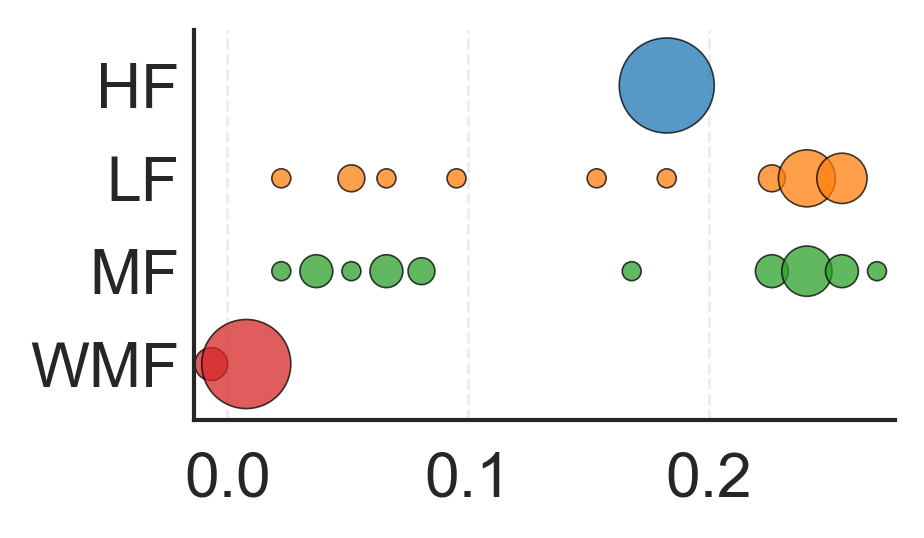

In [6]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
models = MODELS[3::-1]
labels = models.copy()
labels[0] = "WMF"
all_l1_values = np.concatenate([
    np.asarray(mae_errors[m], dtype=float)
    for m in models
])

xmin = float(np.min(all_l1_values))-0.001
xmax = float(np.max(all_l1_values))+0.001
pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)

l1_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=mae_errors,
    n_bins=20,
    models_order=models,
    colors=method_colors,
    labels=labels,
    xlim=l1_xlim,
    save_path="results/l1_1",
)



### L0 Error

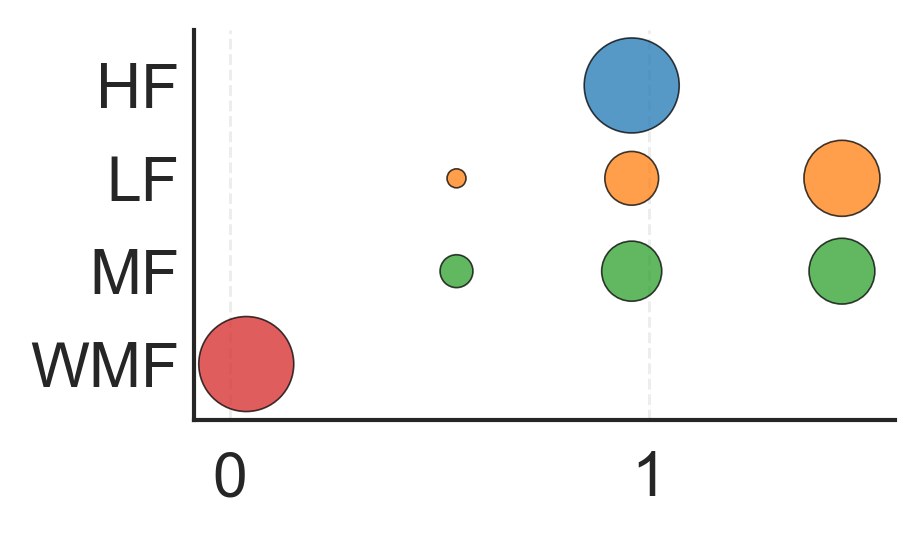

In [7]:
all_l0_values = np.concatenate([
    np.asarray(l0_errors[m], dtype=float)
    for m in models
])

xmin = float(np.min(all_l0_values))-0.01
xmax = float(np.max(all_l0_values))+0.01

pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
l0_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=l0_errors,
    n_bins=20,
    models_order=models,
    colors=method_colors,
    labels=labels,
    xlim=l0_xlim,
    save_path="results/l0_1"
)
